In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path
wells_dir = Path("/content/drive/MyDrive/Stratton Project/Data/wells/Stratton_wells")
print(list(wells_dir.glob("*"))[:20])

[PosixPath('/content/drive/MyDrive/Stratton Project/Data/wells/Stratton_wells/WELL_13.TXT'), PosixPath('/content/drive/MyDrive/Stratton Project/Data/wells/Stratton_wells/WELL_10.TXT'), PosixPath('/content/drive/MyDrive/Stratton Project/Data/wells/Stratton_wells/WELL_14.TXT'), PosixPath('/content/drive/MyDrive/Stratton Project/Data/wells/Stratton_wells/WELL_12.TXT'), PosixPath('/content/drive/MyDrive/Stratton Project/Data/wells/Stratton_wells/WELL_11.TXT'), PosixPath('/content/drive/MyDrive/Stratton Project/Data/wells/Stratton_wells/WELL_1.TXT'), PosixPath('/content/drive/MyDrive/Stratton Project/Data/wells/Stratton_wells/WELL_17.TXT'), PosixPath('/content/drive/MyDrive/Stratton Project/Data/wells/Stratton_wells/VSP_9.TXT'), PosixPath('/content/drive/MyDrive/Stratton Project/Data/wells/Stratton_wells/TABLE3.TXT'), PosixPath('/content/drive/MyDrive/Stratton Project/Data/wells/Stratton_wells/WELL_8.TXT'), PosixPath('/content/drive/MyDrive/Stratton Project/Data/wells/Stratton_wells/WELL_5.

In [4]:
well_path = Path("/content/drive/MyDrive/Stratton Project/Data/wells/Stratton_wells/WELL_1.TXT")

with open(well_path, "r") as f:
    for i, line in enumerate(f):
        if i < 60:          # first 60 lines
            print(f"{i:3d}: {line}", end="")
        else:
            break

  0:     DEPTH        SP        SN        LN
  1:                                        
  2: 
  3:                                        
  4:    3000.0      8.17      3.29      3.11
  5:    3001.0      9.12      2.86      2.72
  6:    3002.0      9.68      2.46      2.44
  7:    3003.0     10.15      2.09      2.30
  8:    3004.0     10.35      1.83      2.30
  9:    3005.0     10.50      1.77      2.35
 10:    3006.0     10.45      1.82      2.43
 11:    3007.0      9.92      2.01      2.56
 12:    3008.0      8.59      2.57      2.70
 13:    3009.0      6.56      3.53      2.83
 14:    3010.0      3.62      4.43      2.92
 15:    3011.0      1.11      5.01      2.94
 16:    3012.0     -0.60      5.10      2.92
 17:    3013.0     -1.83      5.19      2.84
 18:    3014.0     -2.68      5.28      2.75
 19:    3015.0     -2.68      5.33      2.60
 20:    3016.0     -2.18      5.08      2.45
 21:    3017.0     -1.54      4.85      2.36
 22:    3018.0     -0.40      4.54      2.35
 23:

In [5]:
with open(well_path, "r") as f:
    print("Total lines:", sum(1 for _ in f))

Total lines: 3462


In [6]:
well_path = Path("/content/drive/MyDrive/Stratton Project/Data/wells/Stratton_wells/WELL_1.TXT")

# Read the file (skip blank header lines)
df = pd.read_csv(well_path, sep=r'\s+', skiprows=3, names=['DEPTH', 'SP', 'SN', 'LN'])

print(df.head(10))
print("\nDepth range: {:.1f} – {:.1f}".format(df.DEPTH.min(), df.DEPTH.max()))
print("Number of samples:", len(df))

    DEPTH     SP    SN    LN
0  3000.0   8.17  3.29  3.11
1  3001.0   9.12  2.86  2.72
2  3002.0   9.68  2.46  2.44
3  3003.0  10.15  2.09  2.30
4  3004.0  10.35  1.83  2.30
5  3005.0  10.50  1.77  2.35
6  3006.0  10.45  1.82  2.43
7  3007.0   9.92  2.01  2.56
8  3008.0   8.59  2.57  2.70
9  3009.0   6.56  3.53  2.83

Depth range: 3000.0 – 6457.0
Number of samples: 3458


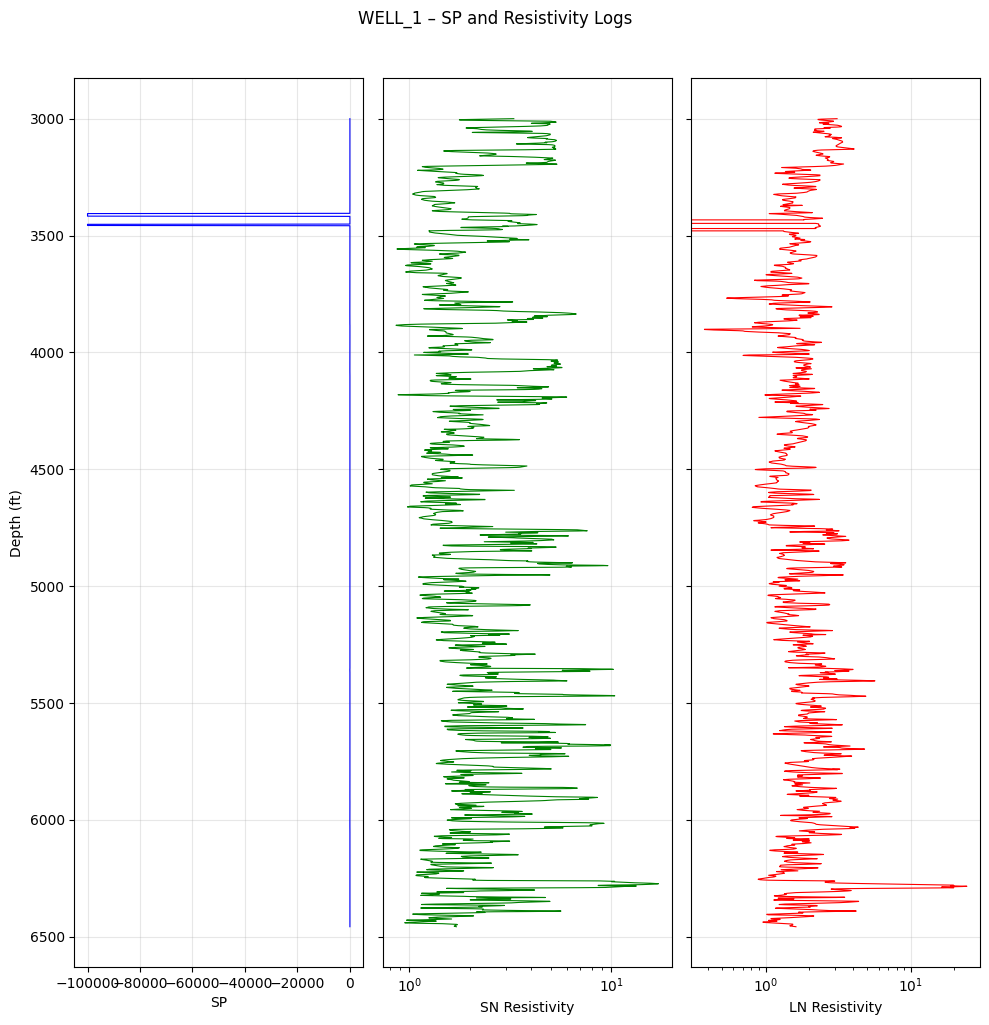

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(10, 10), sharey=True)

# SP
axes[0].plot(df.SP, df.DEPTH, color='blue', linewidth=0.8)
axes[0].set_xlabel('SP')
axes[0].set_ylabel('Depth (ft)')
axes[0].grid(True, alpha=0.3)
axes[0].invert_yaxis()          # depth increases downward

# Short Normal resistivity
axes[1].plot(df.SN, df.DEPTH, color='green', linewidth=0.8)
axes[1].set_xlabel('SN Resistivity')
axes[1].set_xscale('log')       # resistivity is usually log scale
axes[1].grid(True, alpha=0.3)

# Long Normal resistivity
axes[2].plot(df.LN, df.DEPTH, color='red', linewidth=0.8)
axes[2].set_xlabel('LN Resistivity')
axes[2].set_xscale('log')
axes[2].grid(True, alpha=0.3)

plt.suptitle('WELL_1 – SP and Resistivity Logs', y=1.02)
plt.tight_layout()
plt.show()

In [8]:
#Cleaning the data

print("SP  min / max:", df.SP.min(), df.SP.max())
print("SN  min / max:", df.SN.min(), df.SN.max())
print("LN  min / max:", df.LN.min(), df.LN.max())

# How many extreme values?
print("\nSP values < -1000 :", (df.SP < -1000).sum())
print("SP values >  1000 :", (df.SP > 1000).sum())

SP  min / max: -99999.0 13.78
SN  min / max: 0.86 17.08
LN  min / max: -99999.0 24.36

SP values < -1000 : 18
SP values >  1000 : 0


In [9]:
#Replacing the nulls

# Common null handling for this kind of file
df_clean = df.copy()

# Treat extreme SP values as null
df_clean.loc[df_clean.SP.abs() > 1000, 'SP'] = pd.NA

# Resistivity should never be negative or extremely large
df_clean.loc[(df_clean.SN <= 0) | (df_clean.SN > 1000), 'SN'] = pd.NA
df_clean.loc[(df_clean.LN <= 0) | (df_clean.LN > 1000), 'LN'] = pd.NA

print("After cleaning:")
print(df_clean.describe())

After cleaning:
             DEPTH           SP           SN           LN
count  3458.000000  3440.000000  3458.000000  3435.000000
mean   4728.500000     5.783471     2.477374     1.929825
std     998.382943     8.293145     1.692849     1.329051
min    3000.000000   -53.080000     0.860000     0.380000
25%    3864.250000     5.547500     1.470000     1.380000
50%    4728.500000     8.520000     1.850000     1.700000
75%    5592.750000    10.250000     2.830000     2.180000
max    6457.000000    13.780000    17.080000    24.360000


In [10]:
# Cleaning
df_clean = df.copy()

# SP: remove extreme nulls
df_clean.loc[df_clean.SP.abs() > 1000, 'SP'] = pd.NA

# Resistivity: remove non-physical values
df_clean.loc[(df_clean.SN <= 0) | (df_clean.SN > 1000), 'SN'] = pd.NA
df_clean.loc[(df_clean.LN <= 0) | (df_clean.LN > 1000), 'LN'] = pd.NA

print("After cleaning:")
print(df_clean.describe())

After cleaning:
             DEPTH           SP           SN           LN
count  3458.000000  3440.000000  3458.000000  3435.000000
mean   4728.500000     5.783471     2.477374     1.929825
std     998.382943     8.293145     1.692849     1.329051
min    3000.000000   -53.080000     0.860000     0.380000
25%    3864.250000     5.547500     1.470000     1.380000
50%    4728.500000     8.520000     1.850000     1.700000
75%    5592.750000    10.250000     2.830000     2.180000
max    6457.000000    13.780000    17.080000    24.360000


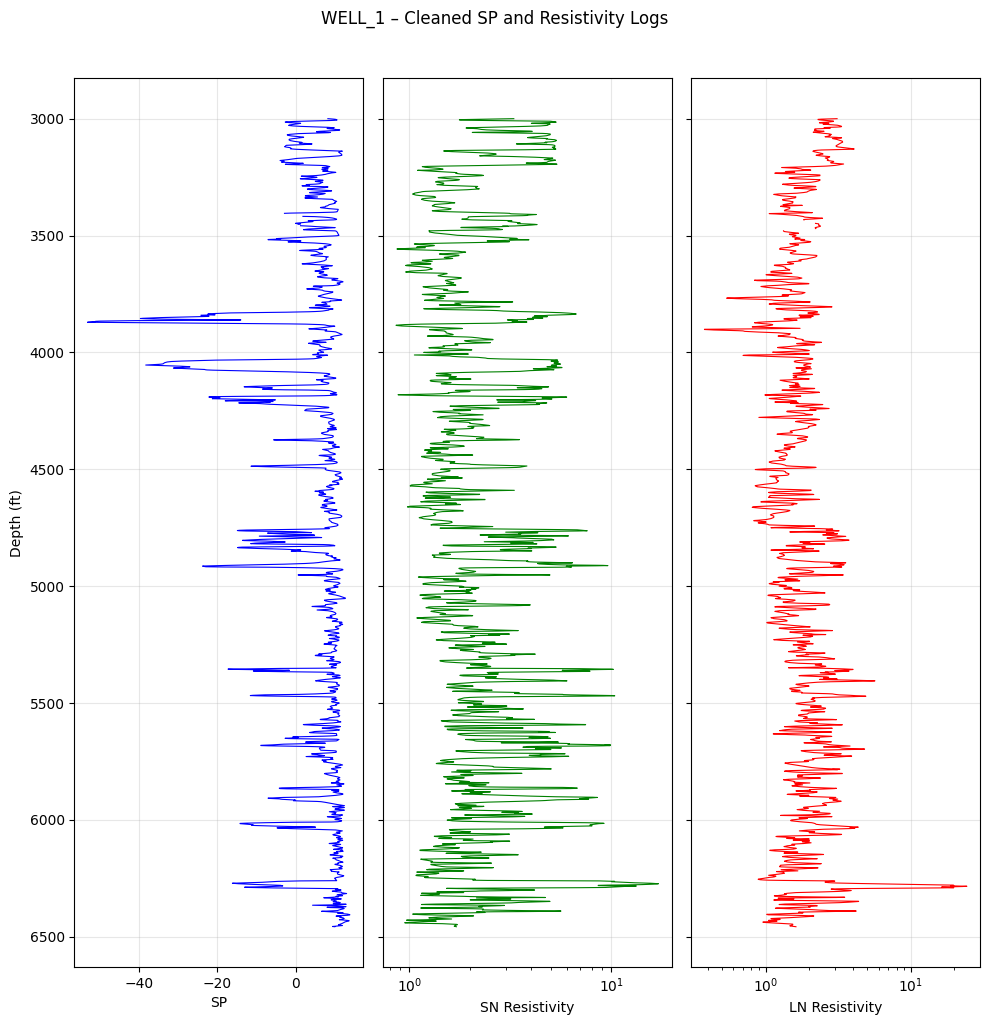

In [11]:
# Plot with cleaned data
fig, axes = plt.subplots(1, 3, figsize=(10, 10), sharey=True)

# SP
axes[0].plot(df_clean.SP, df_clean.DEPTH, color='blue', linewidth=0.8)
axes[0].set_xlabel('SP')
axes[0].set_ylabel('Depth (ft)')
axes[0].grid(True, alpha=0.3)
axes[0].invert_yaxis()

# Short Normal resistivity (log scale)
axes[1].plot(df_clean.SN, df_clean.DEPTH, color='green', linewidth=0.8)
axes[1].set_xlabel('SN Resistivity')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)

# Long Normal resistivity (log scale)
axes[2].plot(df_clean.LN, df_clean.DEPTH, color='red', linewidth=0.8)
axes[2].set_xlabel('LN Resistivity')
axes[2].set_xscale('log')
axes[2].grid(True, alpha=0.3)

plt.suptitle('WELL_1 – Cleaned SP and Resistivity Logs', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
def load_well10(path):
    df = pd.read_csv(path, sep=r'\s+', skiprows=3,
                     names=['DEPTH', 'GR', 'SP', 'SFLU', 'ILM', 'RT', 'NPSS', 'RHOB'])

    # Light cleaning – only remove extreme nulls
    for col in ['GR', 'SP', 'SFLU', 'ILM', 'RT', 'NPSS', 'RHOB']:
        df.loc[df[col].abs() > 1e5, col] = pd.NA   # extreme nulls

    # Resistivity should be positive
    for col in ['SFLU', 'ILM', 'RT']:
        df.loc[df[col] <= 0, col] = pd.NA

    return df

well10_path = Path("/content/drive/MyDrive/Stratton Project/Data/wells/Stratton_wells/WELL_10.TXT")
df10 = load_well10(well10_path)

print(df10.head())
print("\nDepth range: {:.0f} – {:.0f} ft".format(df10.DEPTH.min(), df10.DEPTH.max()))
print(df10.describe().round(2))

    DEPTH     GR     SP  SFLU   ILM    RT    NPSS    RHOB
0  4000.0  83.36 -10.34  1.56  1.45  1.06  0.3715  2.3046
1  4001.0  81.09 -10.93  1.66  1.52  1.11  0.4590  2.3018
2  4002.0  77.01 -12.40  1.78  1.65  1.67  0.4071  2.3154
3  4003.0  71.42 -12.67  1.91  1.79  1.85  0.3584  2.3490
4  4004.0  63.61 -11.57  2.39  1.95  2.02  0.3321  2.3758

Depth range: 4000 – 7580 ft
         DEPTH       GR       SP     SFLU      ILM       RT     NPSS     RHOB
count  3581.00  3581.00  3581.00  3581.00  3581.00  3581.00  3581.00  3581.00
mean   5790.00    90.46   -13.22     2.83     2.11     2.14     0.33     2.35
std    1033.89    24.83    19.46     2.71     1.80     1.93     0.06     0.07
min    4000.00    34.79   -94.92     0.55     0.61     0.60     0.11     2.12
25%    4895.00    73.92   -11.40     1.54     1.35     1.37     0.28     2.30
50%    5790.00    88.39    -4.55     2.02     1.72     1.74     0.33     2.34
75%    6685.00   105.76    -2.22     3.17     2.34     2.33     0.38     2.39

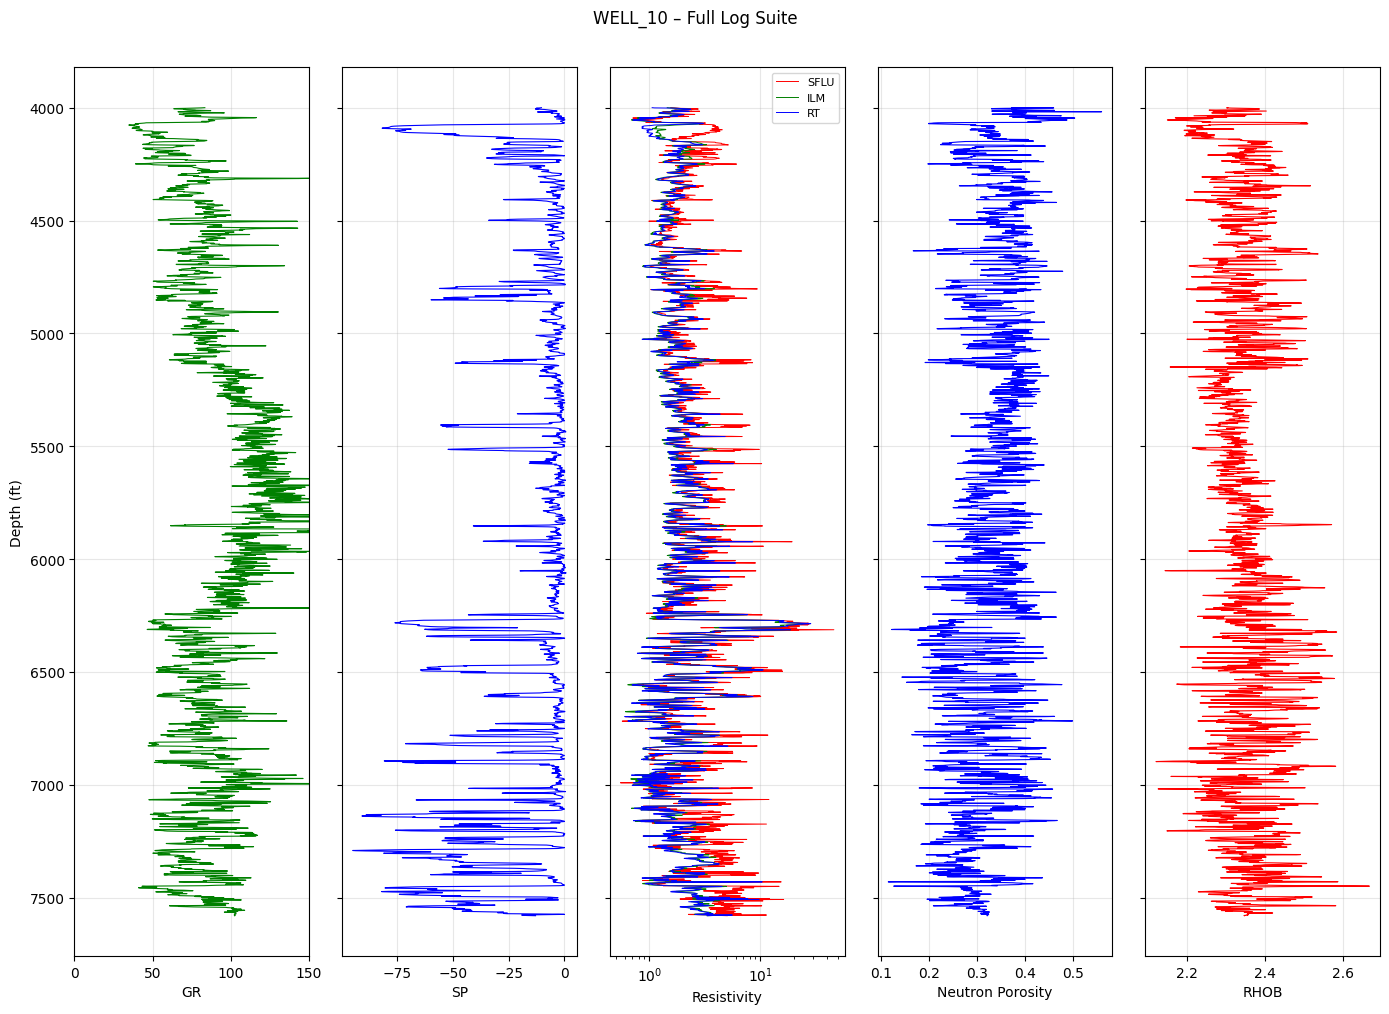

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(14, 10), sharey=True)

# Gamma Ray
axes[0].plot(df10.GR, df10.DEPTH, 'g', linewidth=0.8)
axes[0].set_xlabel('GR')
axes[0].set_xlim(0, 150)
axes[0].grid(True, alpha=0.3)

# SP
axes[1].plot(df10.SP, df10.DEPTH, 'b', linewidth=0.8)
axes[1].set_xlabel('SP')
axes[1].grid(True, alpha=0.3)

# Resistivities
axes[2].plot(df10.SFLU, df10.DEPTH, 'r', linewidth=0.7, label='SFLU')
axes[2].plot(df10.ILM,  df10.DEPTH, 'g', linewidth=0.7, label='ILM')
axes[2].plot(df10.RT,   df10.DEPTH, 'b', linewidth=0.7, label='RT')
axes[2].set_xlabel('Resistivity')
axes[2].set_xscale('log')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

# Neutron
axes[3].plot(df10.NPSS, df10.DEPTH, 'b', linewidth=0.8)
axes[3].set_xlabel('Neutron Porosity')
axes[3].grid(True, alpha=0.3)

# Density
axes[4].plot(df10.RHOB, df10.DEPTH, 'r', linewidth=0.8)
axes[4].set_xlabel('RHOB')
axes[4].grid(True, alpha=0.3)

for ax in axes:
    ax.invert_yaxis()

axes[0].set_ylabel('Depth (ft)')
plt.suptitle('WELL_10 – Full Log Suite', y=1.01)
plt.tight_layout()
plt.show()

In [14]:
# Around 4065–4100 ft there is a strong negative SP deflection (down to ~–80) that lines up with lower GR and changes in resistivity and density. This is a classic sand signature.
# GR shows clear shale/sand differentiation (higher GR = more shale).
# Density (RHOB) and Neutron (NPSS) are present, so we can later look for gas effects (neutron-density crossover).
# Resistivity curves (SFLU, ILM, RT) show invasion profiles in places.

In [15]:
well20_path = Path("/content/drive/MyDrive/Stratton Project/Data/wells/Stratton_wells/WELL_20.TXT")

# Show the first 20–30 lines so we can see the header and columns
with open(well20_path, "r") as f:
    for i, line in enumerate(f):
        if i < 30:
            print(f"{i:3d}: {line}", end="")
        else:
            break

  0:     DEPTH        GR        SP      SFLU       ILM        RT        NPSS        RHOB
  1:                                  (SHALLOW)                                                   
  2: 
  3:                                                                                    
  4:    4516.0     73.15     -2.24      1.67      1.47      1.46      0.3411      2.3487
  5:    4517.0     76.64     -1.98      1.68      1.50      1.51      0.3424      2.3605
  6:    4518.0     78.80     -1.62      1.75      1.55      1.62      0.3365      2.3768
  7:    4519.0     80.08     -1.57      1.84      1.61      1.66      0.3249      2.4000
  8:    4520.0     77.94     -1.38      1.92      1.65      1.68      0.3024      2.4306
  9:    4521.0     76.51     -1.24      1.95      1.68      1.69      0.2869      2.4073
 10:    4522.0     76.59     -1.19      1.84      1.66      1.68      0.2789      2.3843
 11:    4523.0     77.53     -1.16      1.78      1.61      1.66      0.2942      2.3836
 12: 

In [16]:
print("\nTotal lines:", sum(1 for _ in open(well20_path)))


Total lines: 2889


In [17]:
def load_stratton_well_full(path):
    """More robust loader for the full-suite Stratton wells (GR, SP, resistivities, NPHI, RHOB)"""
    df = pd.read_csv(
        path,
        sep=r'\s+',
        skiprows=3,
        names=['DEPTH', 'GR', 'SP', 'SFLU', 'ILM', 'RT', 'NPSS', 'RHOB'],
        engine='python'
    )

    # Force everything to numeric, turning bad values into NaN
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # cleaning
    for col in ['GR', 'SP', 'SFLU', 'ILM', 'RT', 'NPSS', 'RHOB']:
        df.loc[df[col].abs() > 1e5, col] = pd.NA

    for col in ['SFLU', 'ILM', 'RT']:
        df.loc[df[col] <= 0, col] = pd.NA

    # Drop rows where DEPTH is missing
    df = df.dropna(subset=['DEPTH'])

    return df

In [18]:
well20_path = Path("/content/drive/MyDrive/Stratton Project/Data/wells/Stratton_wells/WELL_20.TXT")
df20 = load_stratton_well_full(well20_path)

print(df20.head())
print("\nDepth range: {:.0f} – {:.0f} ft".format(df20.DEPTH.min(), df20.DEPTH.max()))
print("Number of samples:", len(df20))
print(df20.describe().round(2))

    DEPTH     GR    SP  SFLU   ILM    RT    NPSS    RHOB
0  4516.0  73.15 -2.24  1.67  1.47  1.46  0.3411  2.3487
1  4517.0  76.64 -1.98  1.68  1.50  1.51  0.3424  2.3605
2  4518.0  78.80 -1.62  1.75  1.55  1.62  0.3365  2.3768
3  4519.0  80.08 -1.57  1.84  1.61  1.66  0.3249  2.4000
4  4520.0  77.94 -1.38  1.92  1.65  1.68  0.3024  2.4306

Depth range: 4516 – 7400 ft
Number of samples: 2884
         DEPTH       GR       SP     SFLU      ILM       RT     NPSS     RHOB
count  2884.00  2884.00  2884.00  2884.00  2884.00  2884.00  2884.00  2884.00
mean   5957.56    95.42    -6.05     2.80     2.16     2.24     0.32     2.33
std     832.77    23.42     8.15     2.68     1.75     1.86     0.07     0.07
min    4516.00    38.99   -47.26     0.44     0.57     0.48     0.07     2.04
25%    5236.75    79.11    -6.02     1.41     1.30     1.32     0.27     2.28
50%    5957.50    94.96    -3.00     2.01     1.75     1.77     0.32     2.31
75%    6678.25   110.46    -1.54     3.22     2.43     2.51

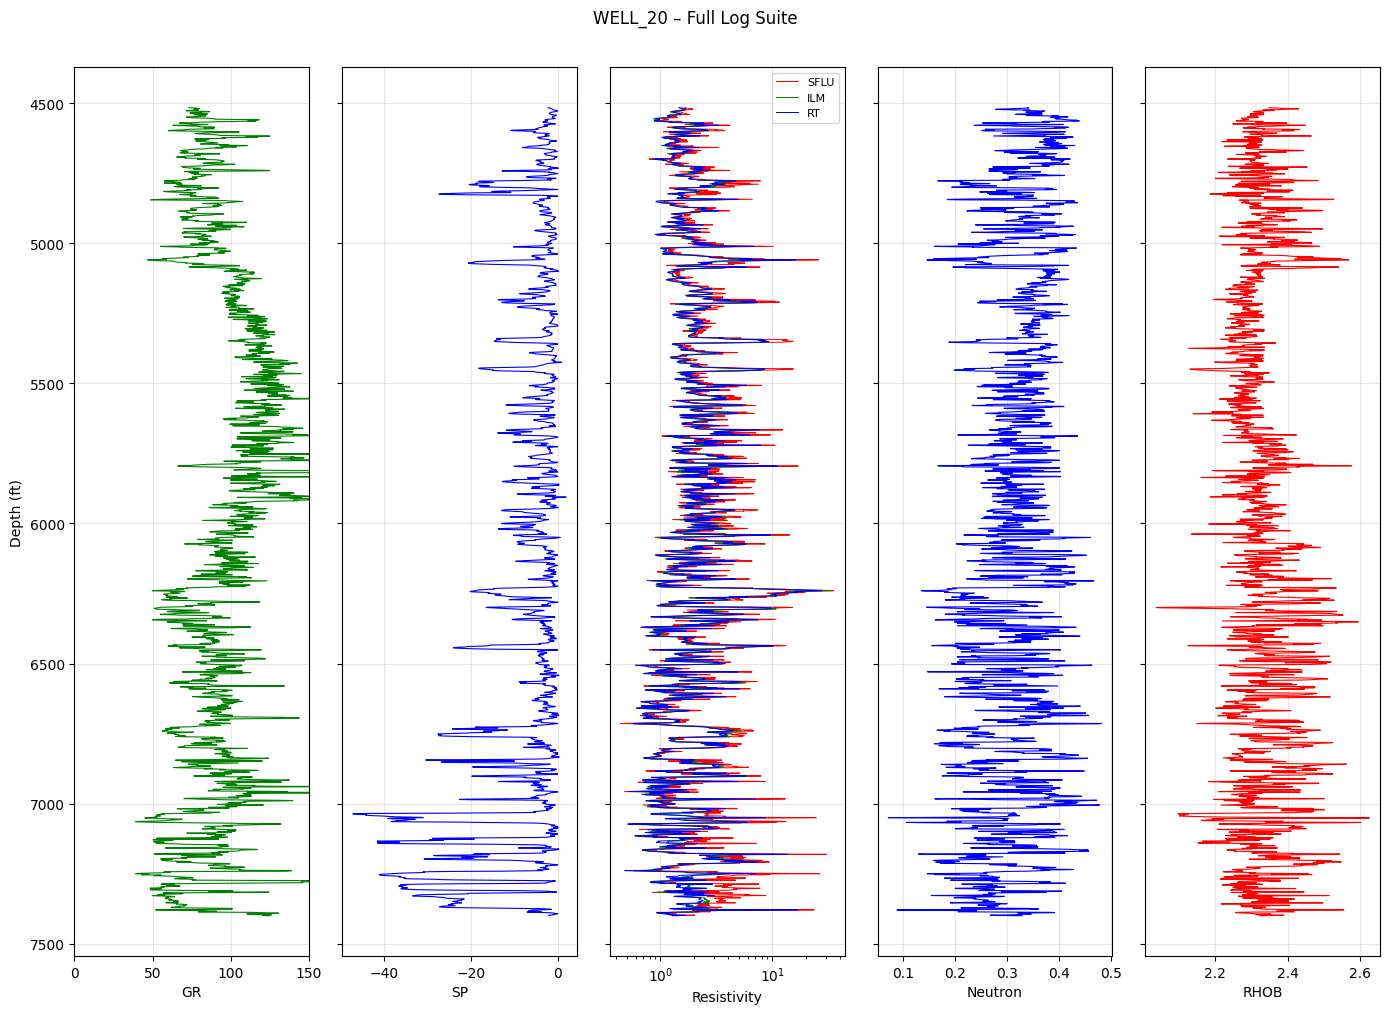

In [19]:
# Same 5-track plot style
fig, axes = plt.subplots(1, 5, figsize=(14, 10), sharey=True)

axes[0].plot(df20.GR, df20.DEPTH, 'g', linewidth=0.8)
axes[0].set_xlabel('GR')
axes[0].set_xlim(0, 150)
axes[0].grid(True, alpha=0.3)

axes[1].plot(df20.SP, df20.DEPTH, 'b', linewidth=0.8)
axes[1].set_xlabel('SP')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df20.SFLU, df20.DEPTH, 'r', linewidth=0.7, label='SFLU')
axes[2].plot(df20.ILM,  df20.DEPTH, 'g', linewidth=0.7, label='ILM')
axes[2].plot(df20.RT,   df20.DEPTH, 'b', linewidth=0.7, label='RT')
axes[2].set_xlabel('Resistivity')
axes[2].set_xscale('log')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

axes[3].plot(df20.NPSS, df20.DEPTH, 'b', linewidth=0.8)
axes[3].set_xlabel('Neutron')
axes[3].grid(True, alpha=0.3)

axes[4].plot(df20.RHOB, df20.DEPTH, 'r', linewidth=0.8)
axes[4].set_xlabel('RHOB')
axes[4].grid(True, alpha=0.3)

for ax in axes:
    ax.invert_yaxis()

axes[0].set_ylabel('Depth (ft)')
plt.suptitle('WELL_20 – Full Log Suite', y=1.01)
plt.tight_layout()
plt.show()

In [20]:
# time-to-depth approximation
# TWT to depth: Depth ≈ (TWT / 2) * V_avg

def twt_to_depth(twt_ms, v_avg_ft_s):
    """Approximate depth from two-way time using constant average velocity"""
    twt_s = twt_ms / 1000.0
    depth = (twt_s / 2.0) * v_avg_ft_s
    return depth

# Test a few reasonable average velocities for this area
velocities = [7500, 8000, 8500, 9000]   # ft/s

print("Approximate depth range for seismic package 1700–2400 ms:\n")
for v in velocities:
    d1 = twt_to_depth(1700, v)
    d2 = twt_to_depth(2400, v)
    print(f"V_avg = {v} ft/s → {d1:.0f} – {d2:.0f} ft")

Approximate depth range for seismic package 1700–2400 ms:

V_avg = 7500 ft/s → 6375 – 9000 ft
V_avg = 8000 ft/s → 6800 – 9600 ft
V_avg = 8500 ft/s → 7225 – 10200 ft
V_avg = 9000 ft/s → 7650 – 10800 ft


In [21]:
print("WELL_1  max depth: {:.0f} ft".format(df.DEPTH.max()))
print("WELL_10 max depth: {:.0f} ft".format(df10.DEPTH.max()))
print("WELL_20 max depth: {:.0f} ft".format(df20.DEPTH.max()))

WELL_1  max depth: 6457 ft
WELL_10 max depth: 7580 ft
WELL_20 max depth: 7400 ft


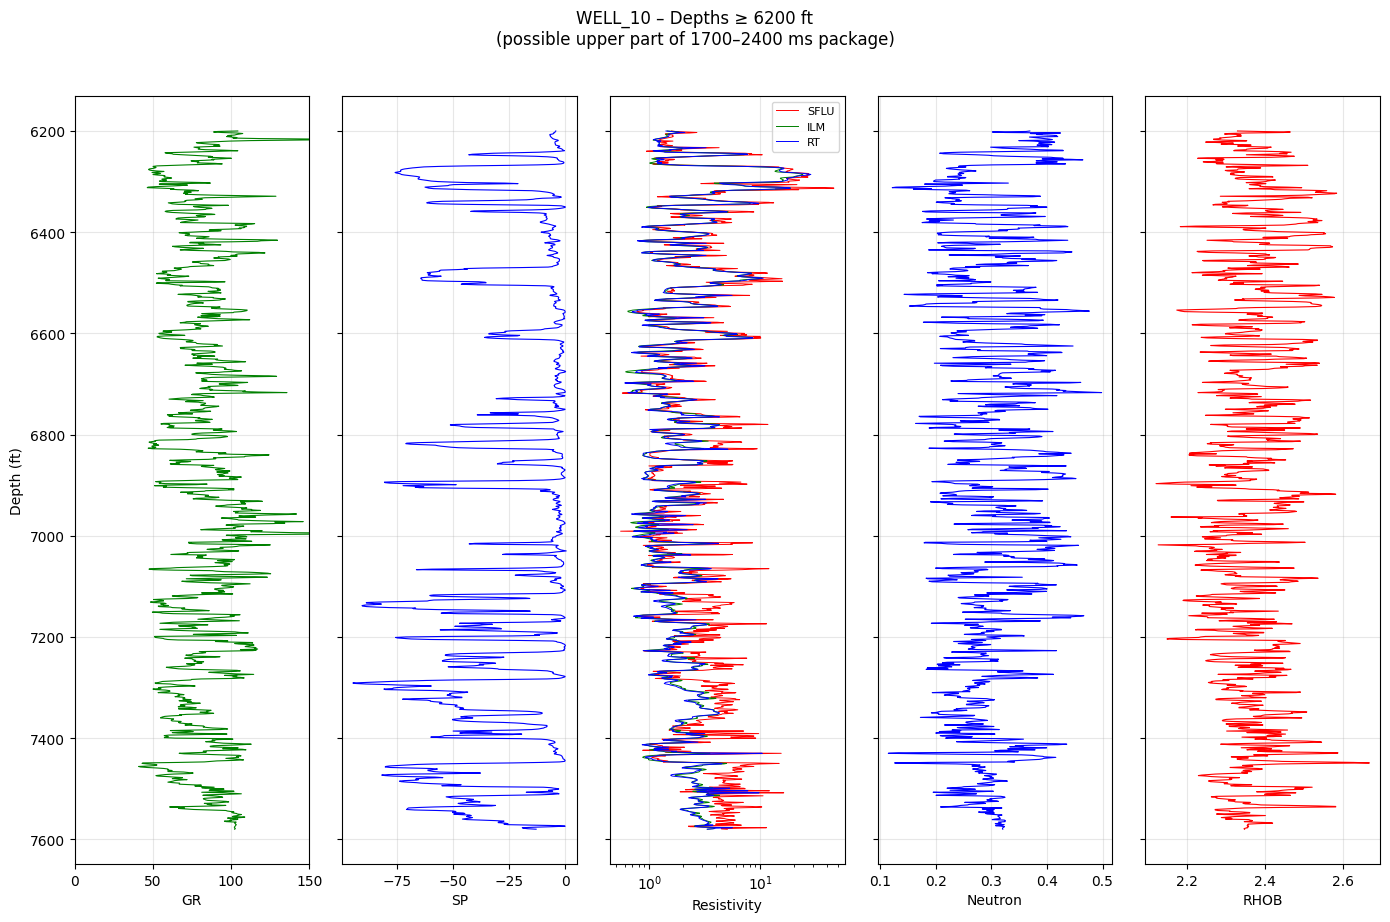

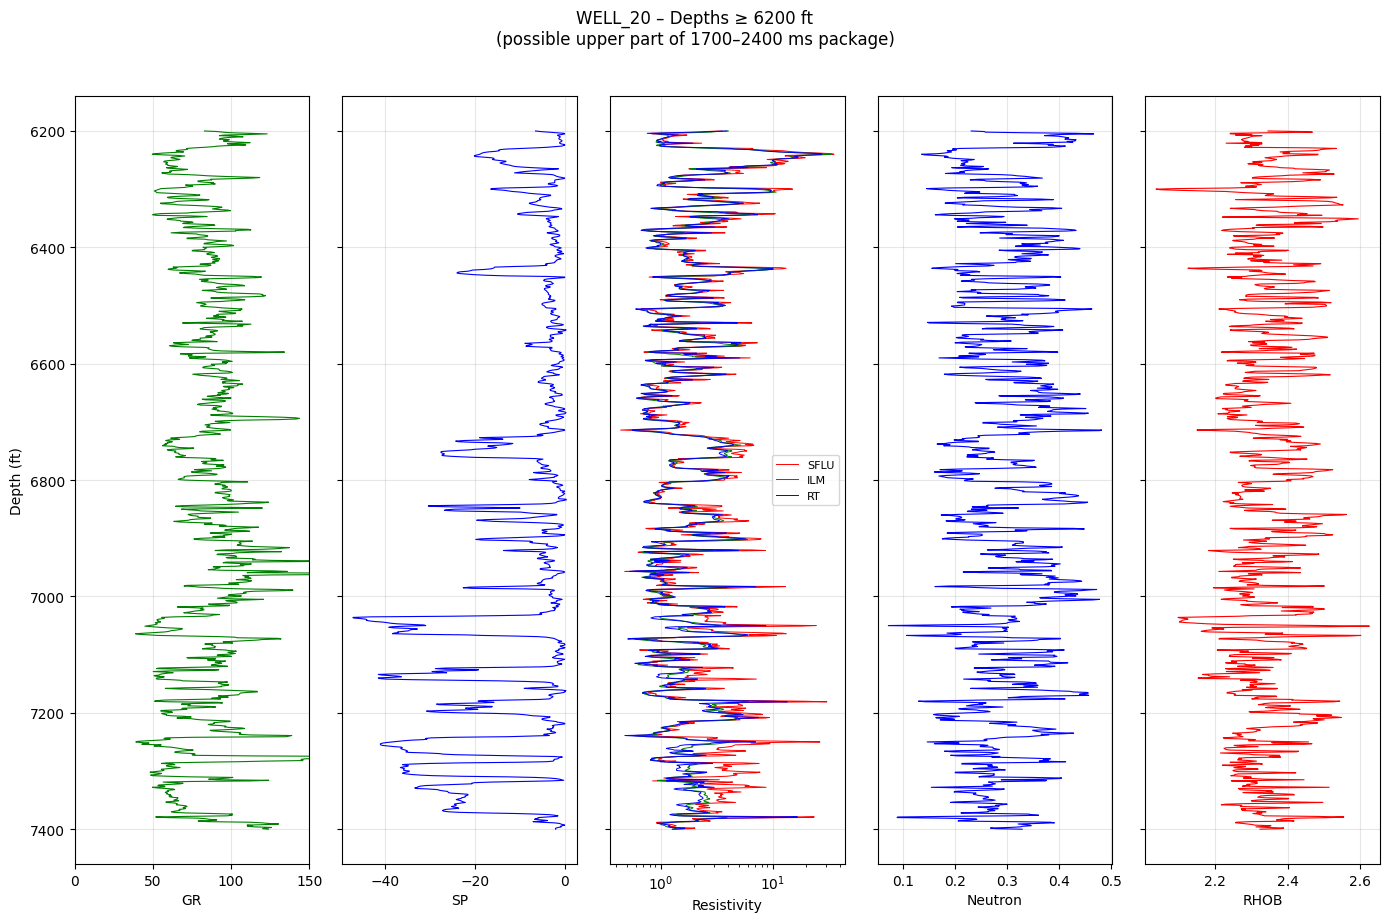

In [22]:
def plot_deep_section(df, well_name, depth_min=6000):
    """Plot the deeper part of a full-suite well"""
    df_deep = df[df.DEPTH >= depth_min].copy()

    if len(df_deep) == 0:
        print(f"No data deeper than {depth_min} ft in {well_name}")
        return

    fig, axes = plt.subplots(1, 5, figsize=(14, 9), sharey=True)

    axes[0].plot(df_deep.GR, df_deep.DEPTH, 'g', linewidth=0.8)
    axes[0].set_xlabel('GR')
    axes[0].set_xlim(0, 150)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(df_deep.SP, df_deep.DEPTH, 'b', linewidth=0.8)
    axes[1].set_xlabel('SP')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(df_deep.SFLU, df_deep.DEPTH, 'r', linewidth=0.7, label='SFLU')
    axes[2].plot(df_deep.ILM,  df_deep.DEPTH, 'g', linewidth=0.7, label='ILM')
    axes[2].plot(df_deep.RT,   df_deep.DEPTH, 'b', linewidth=0.7, label='RT')
    axes[2].set_xlabel('Resistivity')
    axes[2].set_xscale('log')
    axes[2].legend(fontsize=8)
    axes[2].grid(True, alpha=0.3)

    axes[3].plot(df_deep.NPSS, df_deep.DEPTH, 'b', linewidth=0.8)
    axes[3].set_xlabel('Neutron')
    axes[3].grid(True, alpha=0.3)

    axes[4].plot(df_deep.RHOB, df_deep.DEPTH, 'r', linewidth=0.8)
    axes[4].set_xlabel('RHOB')
    axes[4].grid(True, alpha=0.3)

    for ax in axes:
        ax.invert_yaxis()

    axes[0].set_ylabel('Depth (ft)')
    plt.suptitle(f'{well_name} – Depths ≥ {depth_min} ft\n(possible upper part of 1700–2400 ms package)', y=1.02)
    plt.tight_layout()
    plt.show()

# Plot for deep sections
plot_deep_section(df10, "WELL_10", depth_min=6200)
plot_deep_section(df20, "WELL_20", depth_min=6200)

In [23]:
#“A sand-prone interval is present near the base of WELL_10 at a depth
#that is consistent with the upper portion of the high-amplitude seismic package under a reasonable average-velocity assumption.”

In [24]:
# The high-amplitude seismic package (≈1600–2100 ms) was examined on vertical sections and RMS maps. Using average velocities
# of 7500–8000 ft/s, this time interval roughly corresponds to depths of ~6400–9600 ft. WELL_10 reaches 7580 ft and encounters a clear sand
# signature (low GR, negative SP) near 7425 ft, which falls within the upper part of the estimated depth window.
# While a precise well tie is not available, the presence of sand-prone lithology at a compatible depth supports the
# interpretation that the seismic anomaly is at least partly related to Frio fluvial sands.

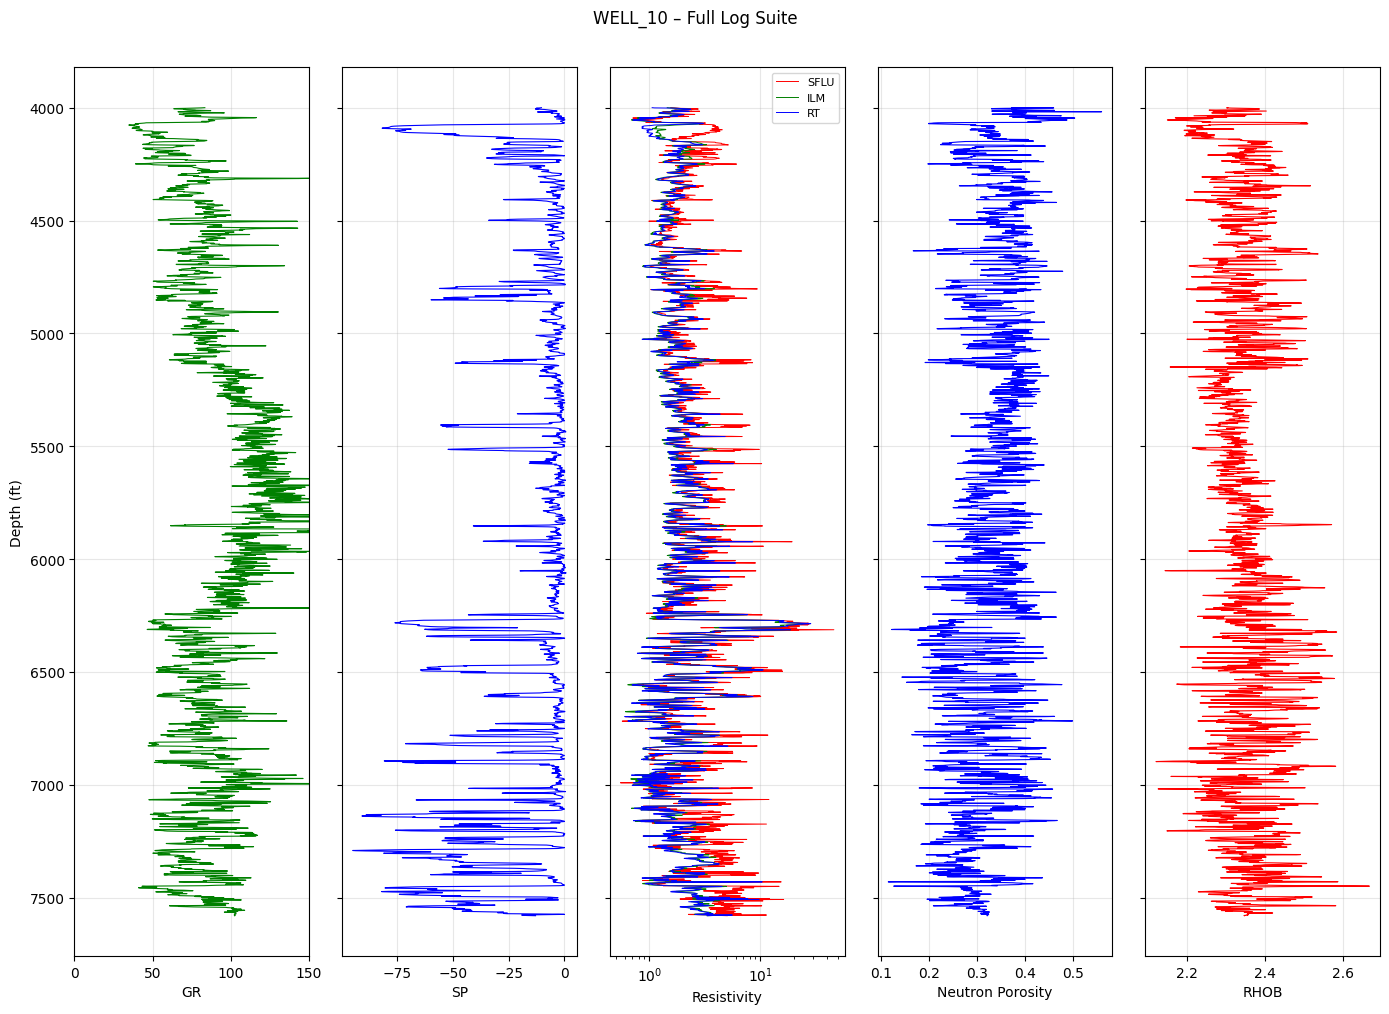

In [26]:
# Figure 4

fig, axes = plt.subplots(1, 5, figsize=(14, 10), sharey=True)

# 1. Gamma Ray
axes[0].plot(df10.GR, df10.DEPTH, 'g', linewidth=0.8)
axes[0].set_xlabel('GR')
axes[0].set_xlim(0, 150)
axes[0].grid(True, alpha=0.3)

# 2. SP
axes[1].plot(df10.SP, df10.DEPTH, 'b', linewidth=0.8)
axes[1].set_xlabel('SP')
axes[1].grid(True, alpha=0.3)

# 3. Resistivities
axes[2].plot(df10.SFLU, df10.DEPTH, 'r', linewidth=0.7, label='SFLU')
axes[2].plot(df10.ILM,  df10.DEPTH, 'g', linewidth=0.7, label='ILM')
axes[2].plot(df10.RT,   df10.DEPTH, 'b', linewidth=0.7, label='RT')
axes[2].set_xlabel('Resistivity')
axes[2].set_xscale('log')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

# 4. Neutron
axes[3].plot(df10.NPSS, df10.DEPTH, 'b', linewidth=0.8)
axes[3].set_xlabel('Neutron Porosity')
axes[3].grid(True, alpha=0.3)

# 5. Density
axes[4].plot(df10.RHOB, df10.DEPTH, 'r', linewidth=0.8)
axes[4].set_xlabel('RHOB')
axes[4].grid(True, alpha=0.3)

for ax in axes:
    ax.invert_yaxis()

axes[0].set_ylabel('Depth (ft)')
plt.suptitle('WELL_10 – Full Log Suite', y=1.01)
plt.tight_layout()

# Saving the figure
fig.canvas.draw()
# fig.savefig("/content/drive/MyDrive/Stratton Project/Figures/fig4_well10_full.png",
#             dpi=200, bbox_inches="tight", facecolor="white")

plt.show()

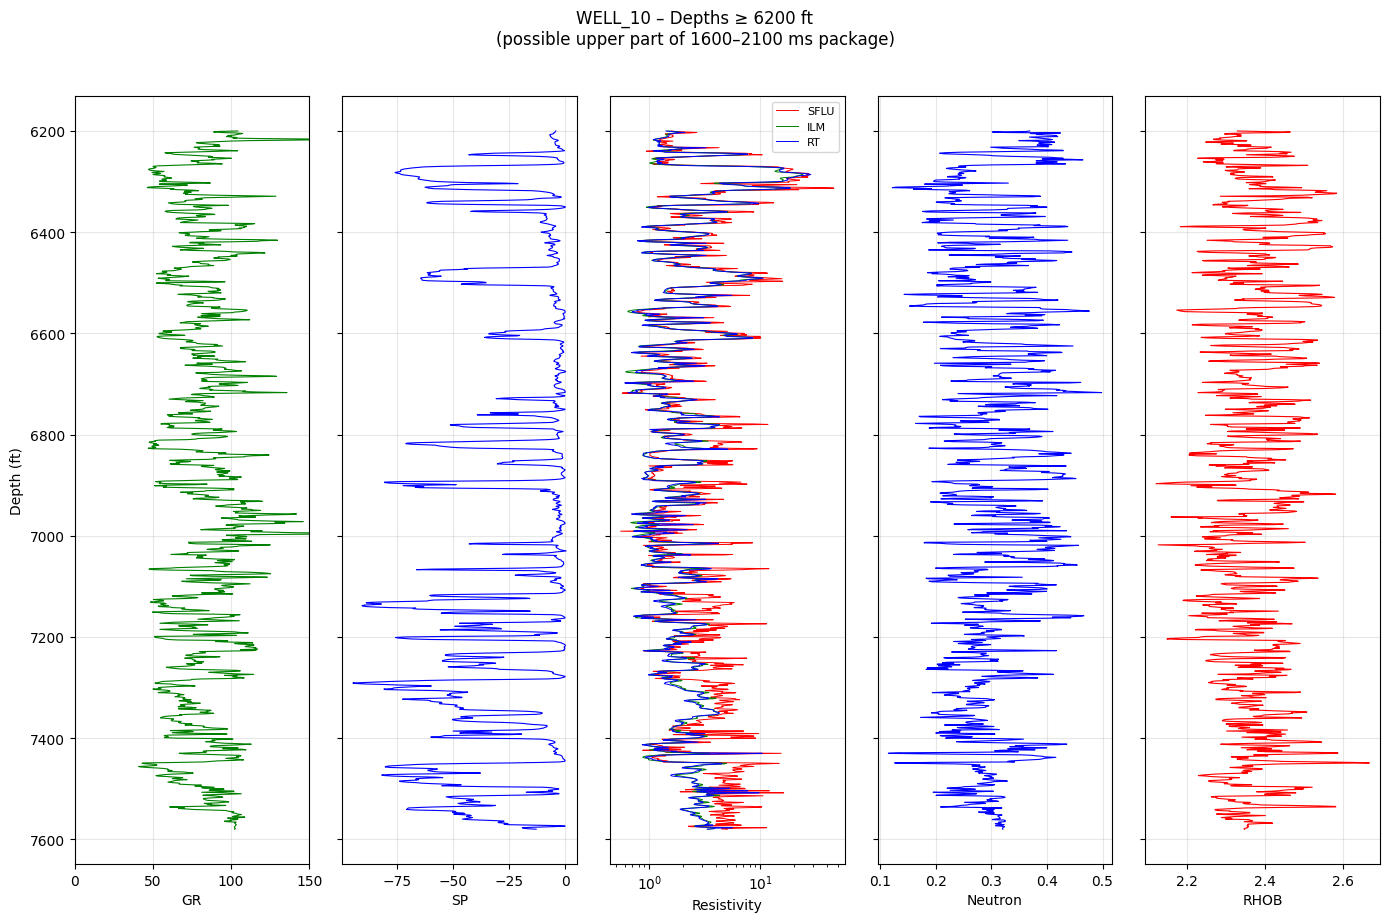

In [32]:
# Figure 5


# WELL_10 Deep Section (≥ 6200 ft)

depth_min = 6200
df_deep = df10[df10.DEPTH >= depth_min].copy()

fig, axes = plt.subplots(1, 5, figsize=(14, 9), sharey=True)

# 1. Gamma Ray
axes[0].plot(df_deep.GR, df_deep.DEPTH, 'g', linewidth=0.8)
axes[0].set_xlabel('GR')
axes[0].set_xlim(0, 150)
axes[0].grid(True, alpha=0.3)

# 2. SP
axes[1].plot(df_deep.SP, df_deep.DEPTH, 'b', linewidth=0.8)
axes[1].set_xlabel('SP')
axes[1].grid(True, alpha=0.3)

# 3. Resistivities
axes[2].plot(df_deep.SFLU, df_deep.DEPTH, 'r', linewidth=0.7, label='SFLU')
axes[2].plot(df_deep.ILM,  df_deep.DEPTH, 'g', linewidth=0.7, label='ILM')
axes[2].plot(df_deep.RT,   df_deep.DEPTH, 'b', linewidth=0.7, label='RT')
axes[2].set_xlabel('Resistivity')
axes[2].set_xscale('log')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

# 4. Neutron
axes[3].plot(df_deep.NPSS, df_deep.DEPTH, 'b', linewidth=0.8)
axes[3].set_xlabel('Neutron')
axes[3].grid(True, alpha=0.3)

# 5. Density
axes[4].plot(df_deep.RHOB, df_deep.DEPTH, 'r', linewidth=0.8)
axes[4].set_xlabel('RHOB')
axes[4].grid(True, alpha=0.3)

for ax in axes:
    ax.invert_yaxis()

axes[0].set_ylabel('Depth (ft)')
plt.suptitle(f'WELL_10 – Depths ≥ {depth_min} ft\n(possible upper part of 1600–2100 ms package)', y=1.02)
plt.tight_layout()

# Saving the figure
fig.canvas.draw()
# fig.savefig("/content/drive/MyDrive/Stratton Project/Figures/fig5_well10_deep_.png",
#             dpi=200, bbox_inches="tight", facecolor="white")

plt.show()

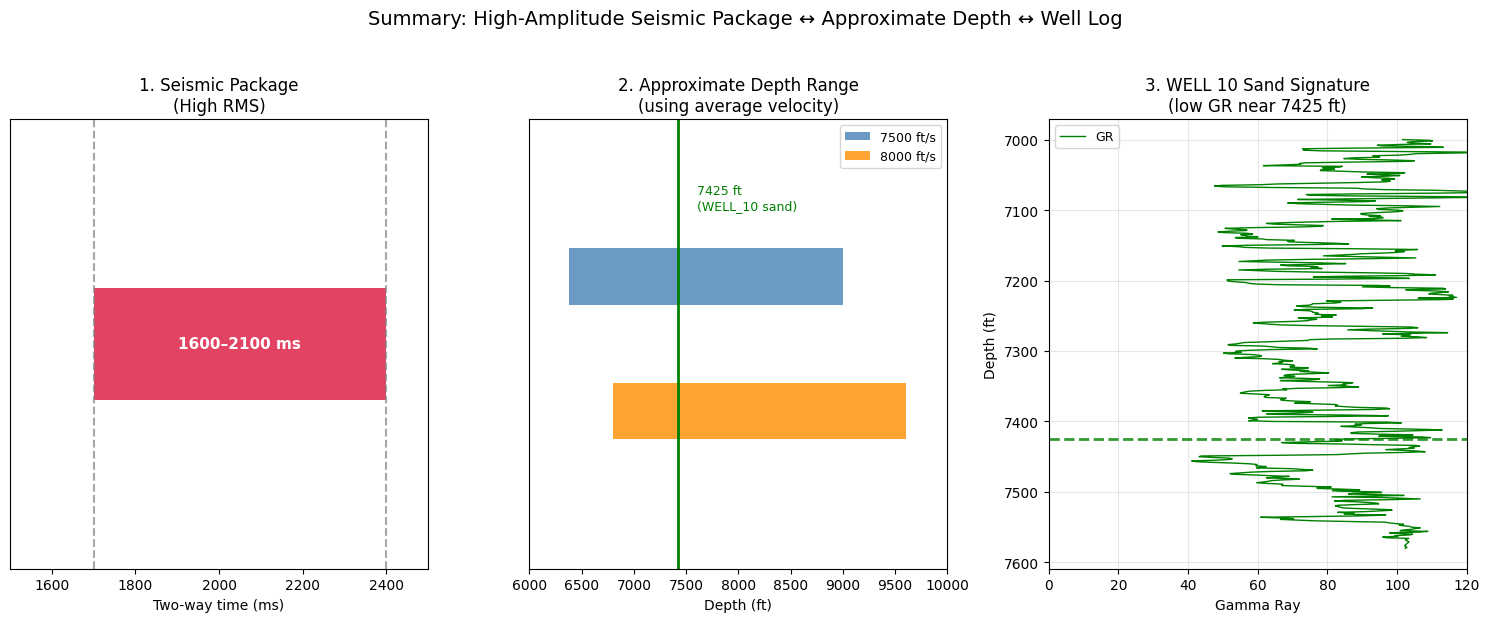

In [31]:
# Figure 6: Summary

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Seismic Time Window
axes[0].barh(0, 700, left=1700, height=0.5, color='crimson', alpha=0.8)
axes[0].set_xlim(1500, 2500)
axes[0].set_ylim(-1, 1)
axes[0].set_yticks([])
axes[0].set_xlabel("Two-way time (ms)")
axes[0].set_title("1. Seismic Package\n(High RMS)", fontsize=12)
axes[0].axvline(1700, color='gray', linestyle='--', alpha=0.7)
axes[0].axvline(2400, color='gray', linestyle='--', alpha=0.7)
axes[0].text(2050, 0, "1600–2100 ms", ha='center', va='center', fontsize=11, color='white', fontweight='bold')

# Approximate Depth Conversion
depths_7500 = [(1700/1000/2)*7500, (2400/1000/2)*7500]  # 6375 – 9000
depths_8000 = [(1700/1000/2)*8000, (2400/1000/2)*8000]  # 6800 – 9600

axes[1].barh(0.3, depths_7500[1]-depths_7500[0], left=depths_7500[0], height=0.25,
             color='steelblue', alpha=0.8, label='7500 ft/s')
axes[1].barh(-0.3, depths_8000[1]-depths_8000[0], left=depths_8000[0], height=0.25,
             color='darkorange', alpha=0.8, label='8000 ft/s')

axes[1].set_xlim(6000, 10000)
axes[1].set_ylim(-1, 1)
axes[1].set_yticks([])
axes[1].set_xlabel("Depth (ft)")
axes[1].set_title("2. Approximate Depth Range\n(using average velocity)", fontsize=12)
axes[1].legend(loc='upper right', fontsize=9)
axes[1].axvline(7425, color='green', linewidth=2, linestyle='-')
axes[1].text(7600, 0.65, "7425 ft\n(WELL_10 sand)", ha='left', va='center', fontsize=9, color='green')

# WELL_10 Sand Signature
df_deep = df10[df10.DEPTH >= 7000].copy()

axes[2].plot(df_deep.GR, df_deep.DEPTH, 'g', linewidth=1.0, label='GR')
axes[2].set_xlim(0, 120)
axes[2].invert_yaxis()
axes[2].set_xlabel("Gamma Ray")
axes[2].set_ylabel("Depth (ft)")
axes[2].set_title("3. WELL 10 Sand Signature\n(low GR near 7425 ft)", fontsize=12)
axes[2].axhline(7425, color='green', linewidth=2, linestyle='--', alpha=0.8)
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=9)

# Title
fig.suptitle("Summary: High-Amplitude Seismic Package ↔ Approximate Depth ↔ Well Log",
             fontsize=14, y=1.03)

plt.tight_layout()

# Saving figure
fig.canvas.draw()
# fig.savefig("/content/drive/MyDrive/Stratton Project/Figures/fig6_summary_.png",
#             dpi=200, bbox_inches="tight", facecolor="white")

plt.show()